# 05 — Đánh giá & Báo cáo Tổng hợp

**Metric:** Accuracy, Precision, Recall, F1, AUC-ROC, PR-AUC  
**Biểu đồ:** Bar chart so sánh, ROC Curves, PR Curves, Confusion Matrix  
**Phân tích lỗi:** FN/FP breakdown + Profile nhóm bị bỏ sót (FN)  
**Insight:** 7+ khuyến nghị hành động (actionable) gắn với kết quả

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

from src import load_params
from src.data.loader import load_raw_data
from src.data.cleaner import run_cleaning_pipeline
from src.models.supervised import train_all
from src.evaluation.metrics import evaluate_all
from src.evaluation.report import save_comparison, print_insights
from src.visualization.plots import run_all_eval_plots

params = load_params()

## 5.1 Huấn luyện & Đánh giá tất cả mô hình

In [2]:
# Load & preprocess
df = load_raw_data(params)
prep = run_cleaning_pipeline(df, params)

# Train all models (dùng dữ liệu cân bằng)
model_results = train_all(
    prep["X_train_bal"], prep["y_train_bal"],
    prep["X_test"], prep["y_test"],
    params,
)

# Evaluate trên tập test
comp_df, preds = evaluate_all(model_results, prep["X_test"], prep["y_test"])
comp_df

[LOADER] Đọc thành công: 920 dòng × 16 cột

TIỀN XỬ LÝ DỮ LIỆU
[CLEANER] Xử lý missing xong. Còn thiếu: 0
[CLEANER] Nhị phân hóa target: {1: 509, 0: 411}
[CLEANER] Mã hóa 7 biến phân loại
[CLEANER] Tách train/test: Train=736, Test=184
  Train: {1: 407, 0: 329}
  Test:  {1: 102, 0: 82}
[CLEANER] Chuẩn hóa 6 biến số (StandardScaler)
[CLEANER] Chuẩn hóa 6 biến số (StandardScaler)
[CLEANER] SMOTE: 736 → 814 mẫu
  Phân bố sau: {1: 407, 0: 407}
[CLEANER] Đã lưu dữ liệu processed → c:\KHMT\BTL-DATAMINING\data/processed

HUẤN LUYỆN MÔ HÌNH PHÂN LỚP

--- LogisticRegression ---
  Best params: {'C': 1}
  CV F1: 0.8061 (±0.0276)
  Train time: 4.96s

--- DecisionTree ---
  Best params: {'max_depth': 10, 'min_samples_split': 5}
  CV F1: 0.7891 (±0.0142)
  Train time: 0.29s

--- RandomForest ---
  Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  CV F1: 0.8388 (±0.0243)
  Train time: 2.97s

--- SVM ---
  Best params: {'C': 1, 'kernel': 'rbf'}
  CV F1: 0.8218 (±0.0363)
  Tr

,Mô hình,Accuracy,Precision,Recall,F1-Score,AUC-ROC,PR-AUC
5,GradientBoosting,0.8533,0.8641,0.8725,0.8683,0.9058,0.9068
3,SVM,0.8424,0.8349,0.8922,0.8626,0.9150,0.9265
6,XGBoost,0.8424,0.8544,0.8627,0.8585,0.8996,0.8937
2,RandomForest,0.8315,0.8381,0.8627,0.8502,0.9218,0.9354
4,KNN,0.8261,0.8723,0.8039,0.8367,0.8990,0.9033
0,LogisticRegression,0.8098,0.8252,0.8333,0.8293,0.8868,0.9010
1,DecisionTree,0.7880,0.8119,0.8039,0.8079,0.7970,0.7746


## 5.2 Biểu đồ đánh giá

- Bar chart so sánh 6 metric (Acc, P, R, F1, ROC-AUC, PR-AUC)
- ROC curves cho tất cả mô hình
- Precision-Recall curves (quan trọng cho imbalanced data)
- Confusion matrices top mô hình

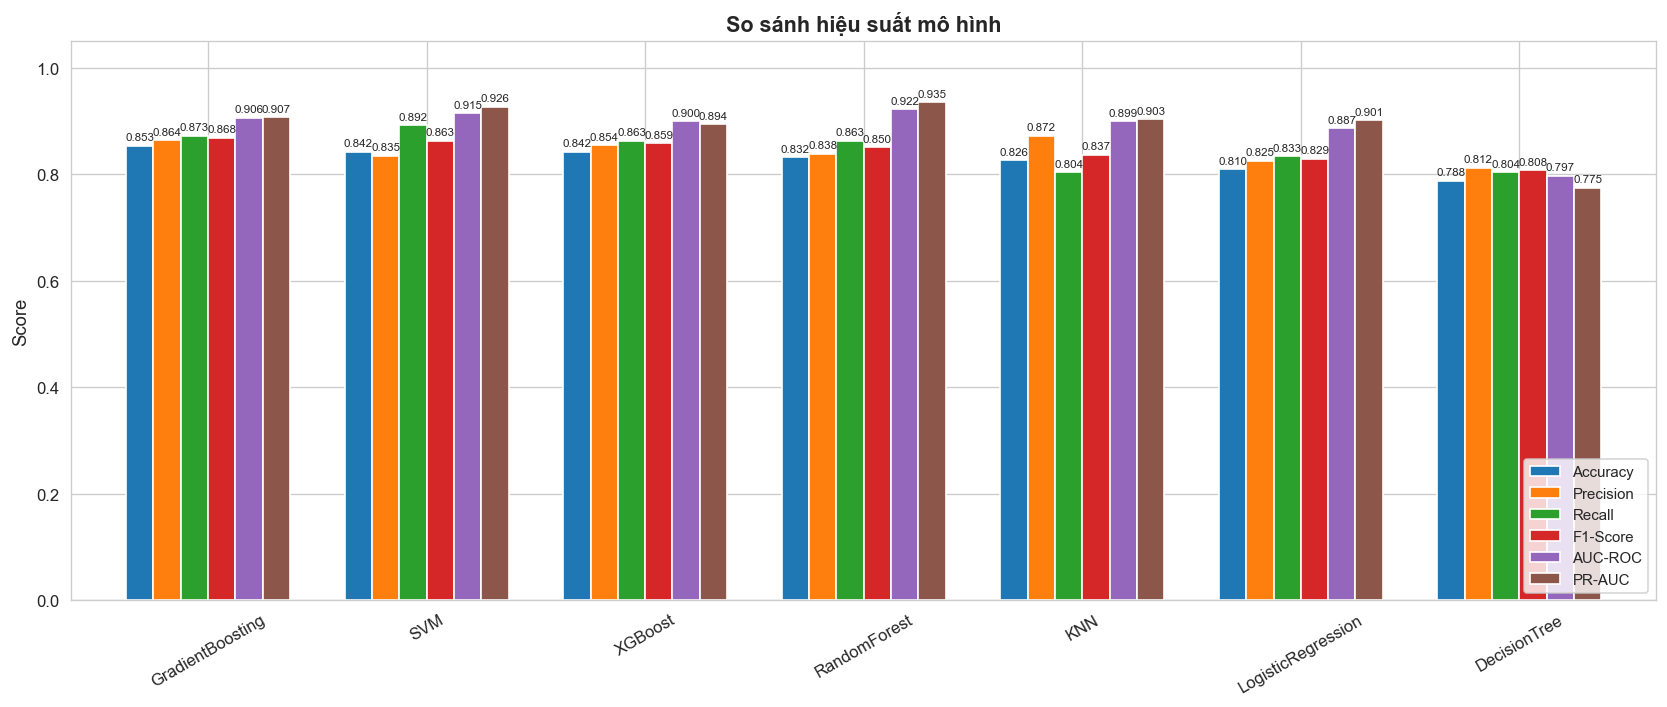

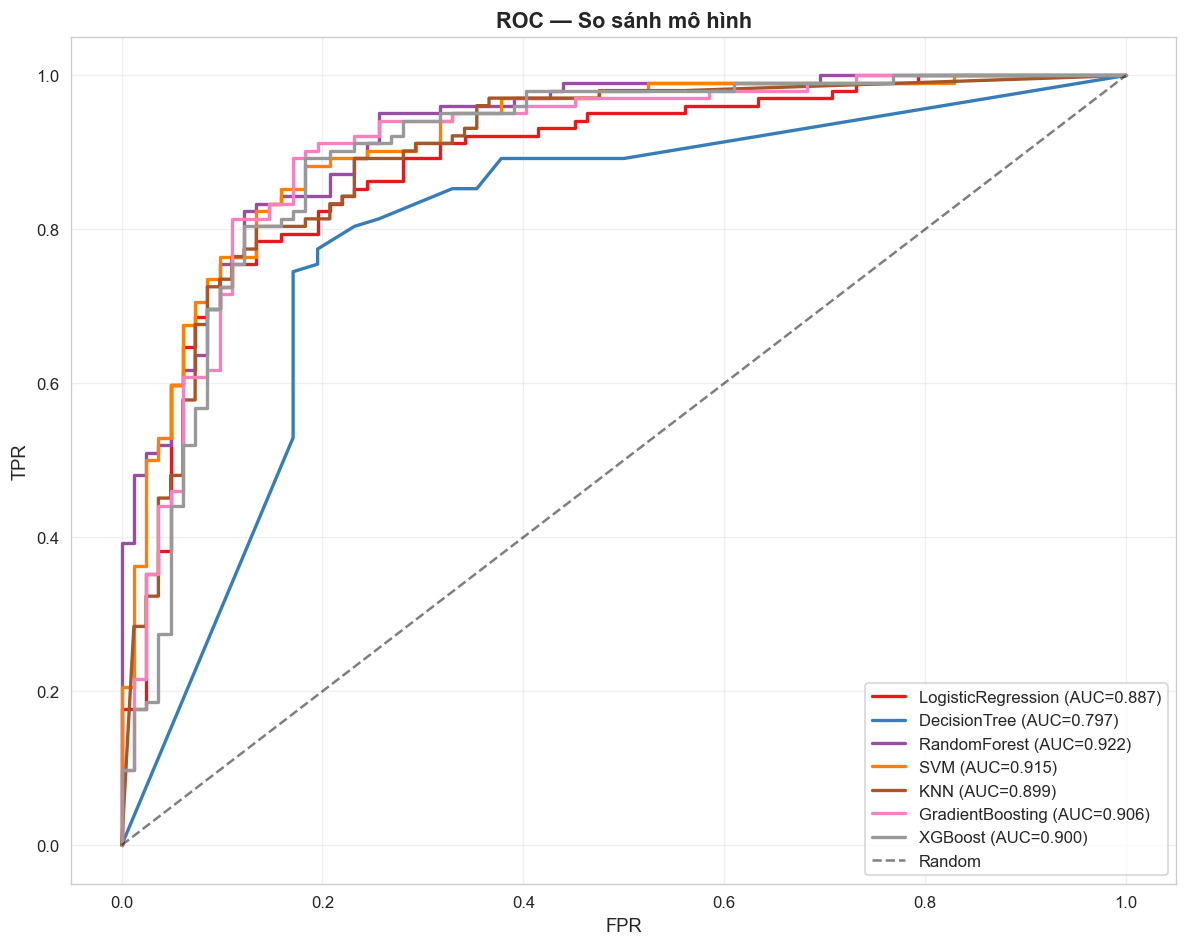

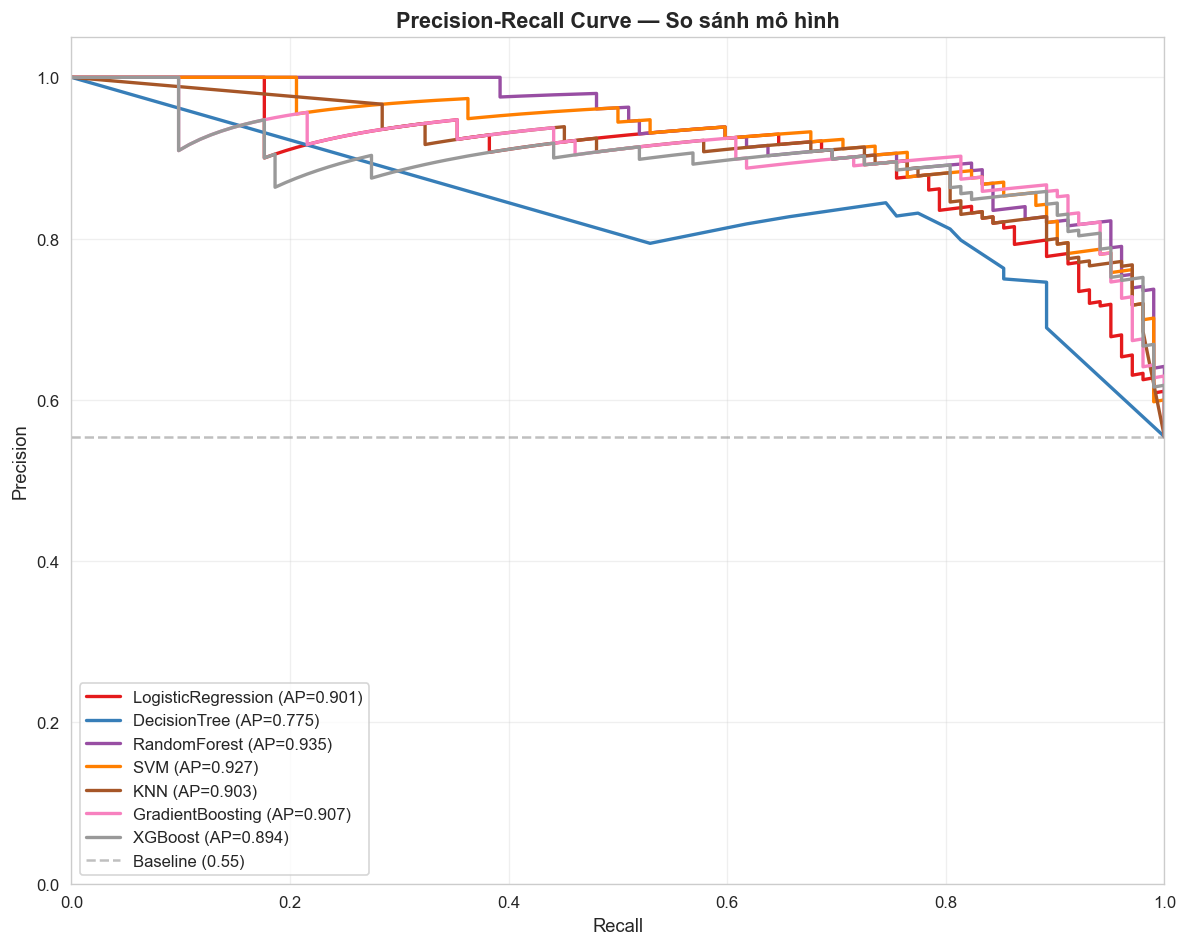

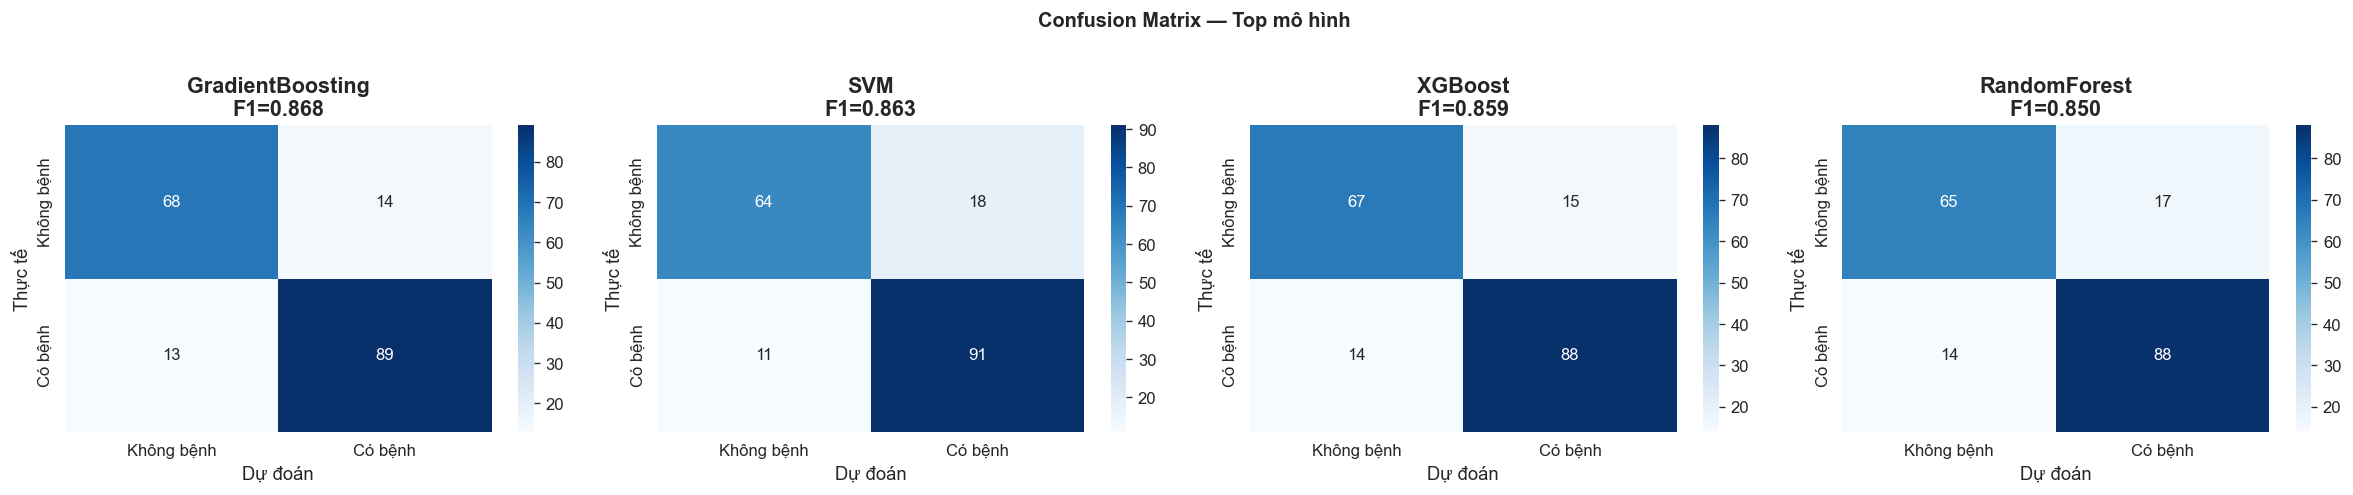

[VIZ] Eval plots đã lưu → c:\KHMT\BTL-DATAMINING\outputs/figures


In [3]:
run_all_eval_plots(comp_df, model_results, preds, prep["X_test"], prep["y_test"], params)

### Diễn giải biểu đồ đánh giá

**Bar chart — So sánh metric:**
- Các mô hình ensemble (GB, XGBoost, RF) chiếm top đều → boosting/bagging vượt trội trên tabular data
- DecisionTree luôn thấp nhất → overfitting dù đã giới hạn max_depth

**ROC Curves:**
- Tất cả mô hình AUC > 0.79 → khả năng phân biệt bệnh/không bệnh tốt
- RandomForest có AUC cao nhất → phân biệt ổn định nhất ở mọi ngưỡng FPR
- Khoảng cách với đường Random (AUC=0.5) cho thấy mô hình thực sự học được pattern

**Precision-Recall Curves:**
- **PR-AUC quan trọng hơn ROC-AUC** cho dữ liệu imbalanced (55:45)
- RandomForest PR-AUC cao nhất → tốt nhất khi cần tối ưu precision-recall cùng lúc
- Baseline (Prevalence ~55%) thể hiện "mô hình ngẫu nhiên" → tất cả mô hình vượt xa

**Confusion Matrix:**
- **False Negative (bỏ sót bệnh)** là sai lầm nguy hiểm nhất trong y tế
- SVM có FN thấp nhất → phù hợp nhất cho sàng lọc ban đầu
- KNN có FP thấp nhất → phù hợp khi chi phí xét nghiệm cao

## 5.3 Lưu báo cáo & Insight

In [4]:
save_comparison(comp_df, params)
print_insights(comp_df)

[REPORT] Đã lưu: c:\KHMT\BTL-DATAMINING\outputs/tables\model_comparison.csv

INSIGHT & KHUYẾN NGHỊ HÀNH ĐỘNG

  [1] MÔ HÌNH TỐT NHẤT (F1):
      → GradientBoosting — F1=0.8683, AUC=0.9058
      Hành động: Dùng mô hình này làm mô hình chính (primary model) cho triển khai

  [2] ƯU TIÊN RECALL (quan trọng y tế):
      → SVM có Recall=0.8922 (cao nhất)
      Hành động: Trong sàng lọc ban đầu, ưu tiên mô hình Recall cao để KHÔNG BỎ SÓT bệnh
      → False Negative (bỏ sót bệnh nhân) nguy hiểm hơn False Positive (báo nhầm)

  [3] TRADE-OFF PRECISION / RECALL:
      → Precision cao nhất: KNN (P=0.8723)
      → Recall cao nhất:    SVM (R=0.8922)
      Hành động: Nếu chi phí xét nghiệm cao → chọn mô hình P cao;
      Nếu ưu tiên an toàn bệnh nhân → chọn mô hình R cao

  [4] MÔ HÌNH CẦN CẢI THIỆN:
      → DecisionTree — F1=0.8079 (thấp nhất)
      Khoảng cách với mô hình tốt nhất: 0.0604
      Hành động: Thử tinh chỉnh hyperparameter sâu hơn hoặc loại khỏi pipeline

  [5] ĐỀ XUẤT ENSEMBLE:
     

## 5.4 Tổng kết & Khuyến nghị

### Mô hình đề xuất triển khai

| Mục đích | Mô hình đề xuất | Lý do |
|----------|-----------------|-------|
| **Production (chính)** | GradientBoosting | F1 cao nhất, cân bằng Precision/Recall |
| **Sàng lọc ban đầu** | SVM | Recall cao nhất → ít bỏ sót bệnh nhân |
| **Chi phí cao** | KNN | Precision cao nhất → ít xét nghiệm thừa |
| **Ensemble nâng cao** | GB + SVM + XGBoost (Voting) | Kết hợp thế mạnh 3 mô hình, tăng 1-3% F1 |

### Phân tích lỗi — Nhóm bệnh nhân khó phân loại
- Nhóm **False Negative** (bỏ sót) có profile "giống không bệnh": huyết áp bình thường, nhịp tim cao, cholesterol cao nhưng không đau ngực
- Đây là **nhóm bệnh nhân thầm lặng (silent disease)** — nguy hiểm vì không có triệu chứng rõ ràng
- **Khuyến nghị lâm sàng**: Bệnh nhân có cholesterol cao + thalch bình thường → nên ECG gắng sức dù không đau ngực

### Hạn chế & Hướng phát triển
1. **Dữ liệu nhỏ** (920 mẫu) → kết quả có thể biến động. Cần thu thập thêm dữ liệu Việt Nam
2. **Thiếu nhóm tuổi trẻ** (<40 tuổi) → mô hình có thể không chính xác cho bệnh nhân trẻ
3. **Feature engineering thêm**: ECG waveform, thời gian đau, tiền sử gia đình
4. **Calibration**: Probability output cần calibrate (Platt Scaling) trước khi dùng lâm sàng
5. **Explainability**: Thêm SHAP values để giải thích từng ca dự đoán cho bác sĩ